# Grouping Statistics - Fastball

In [1]:
import polars as pl
import numpy as np
import pandas as pd
from plotnine import *

In [2]:
outing_table = pl.read_parquet('data/outing_table.parquet')
statcast_relievers = pl.read_parquet('data/statcast_relievers.parquet')

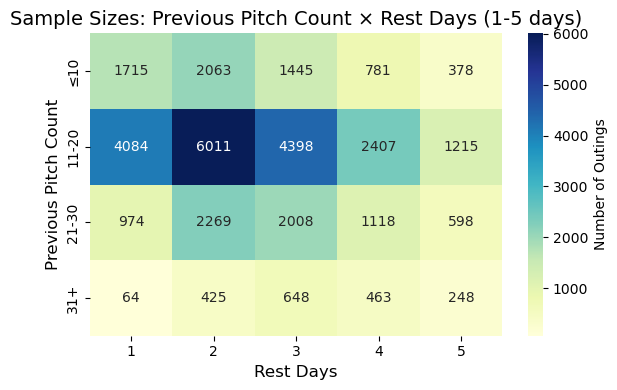

In [3]:
# Sample Size Heatmap with 10-pitch increments
import seaborn as sns
import matplotlib.pyplot as plt

sample_size_data = (outing_table
    .filter((pl.col('rest_days') >= 1) & (pl.col('rest_days') <= 5) & 
            (pl.col('prev_pitch_count').is_not_null()))
    .with_columns([
        pl.when(pl.col('prev_pitch_count') <= 10)
          .then(pl.lit('≤10'))
          .when(pl.col('prev_pitch_count') <= 20)
          .then(pl.lit('11-20'))
          .when(pl.col('prev_pitch_count') <= 30)
          .then(pl.lit('21-30'))
          .otherwise(pl.lit('31+'))
          .alias('prev_pitch_bin')
    ])
    .group_by(['prev_pitch_bin', 'rest_days'])
    .agg([
        pl.len().alias('n')
    ])
    .to_pandas()
    .pivot(index='prev_pitch_bin', columns='rest_days', values='n')
)

sample_size_data = sample_size_data.reindex(['≤10', '11-20', '21-30', '31+'])

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(sample_size_data, annot=True, fmt='g', cmap='YlGnBu', 
            cbar_kws={'label': 'Number of Outings'}, ax=ax)
ax.set_title('Sample Sizes: Previous Pitch Count × Rest Days (1-5 days)', fontsize=14)
ax.set_xlabel('Rest Days', fontsize=12)
ax.set_ylabel('Previous Pitch Count', fontsize=12)
plt.tight_layout()
plt.show()

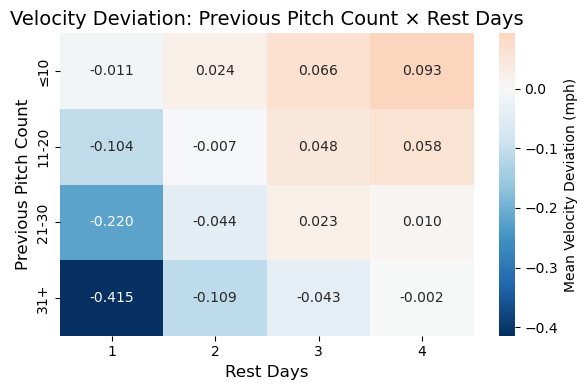

In [4]:
# 1. Velocity Heatmap (rest days 1-4, consolidated bins)
import seaborn as sns
import matplotlib.pyplot as plt

velocity_heatmap = (outing_table
    .filter((pl.col('rest_days') >= 1) & (pl.col('rest_days') <= 4) & 
            (pl.col('prev_pitch_count').is_not_null()))
    .with_columns([
        pl.when(pl.col('prev_pitch_count') <= 10)
          .then(pl.lit('≤10'))
          .when(pl.col('prev_pitch_count') <= 20)
          .then(pl.lit('11-20'))
          .when(pl.col('prev_pitch_count') <= 30)
          .then(pl.lit('21-30'))
          .otherwise(pl.lit('31+'))
          .alias('prev_pitch_bin')
    ])
    .group_by(['prev_pitch_bin', 'rest_days'])
    .agg([
        pl.col('velo_deviation').mean().alias('mean_velo')
    ])
    .to_pandas()
    .pivot(index='prev_pitch_bin', columns='rest_days', values='mean_velo')
)

velocity_heatmap = velocity_heatmap.reindex(['≤10', '11-20', '21-30', '31+'])

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(velocity_heatmap, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Mean Velocity Deviation (mph)'}, ax=ax)
ax.set_title('Velocity Deviation: Previous Pitch Count × Rest Days', fontsize=14)
ax.set_xlabel('Rest Days', fontsize=12)
ax.set_ylabel('Previous Pitch Count', fontsize=12)
plt.tight_layout()
plt.show()

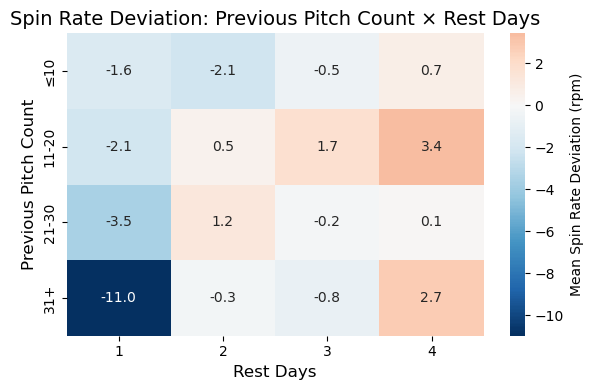

In [5]:
# 2. Spin Rate Heatmap
spin_heatmap = (outing_table
    .filter((pl.col('rest_days') >= 1) & (pl.col('rest_days') <= 4) & 
            (pl.col('prev_pitch_count').is_not_null()))
    .with_columns([
        pl.when(pl.col('prev_pitch_count') <= 10)
          .then(pl.lit('≤10'))
          .when(pl.col('prev_pitch_count') <= 20)
          .then(pl.lit('11-20'))
          .when(pl.col('prev_pitch_count') <= 30)
          .then(pl.lit('21-30'))
          .otherwise(pl.lit('31+'))
          .alias('prev_pitch_bin')
    ])
    .group_by(['prev_pitch_bin', 'rest_days'])
    .agg([
        pl.col('spin_deviation').mean().alias('mean_spin')
    ])
    .to_pandas()
    .pivot(index='prev_pitch_bin', columns='rest_days', values='mean_spin')
)

spin_heatmap = spin_heatmap.reindex(['≤10', '11-20', '21-30', '31+'])

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(spin_heatmap, annot=True, fmt='.1f', cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Mean Spin Rate Deviation (rpm)'}, ax=ax)
ax.set_title('Spin Rate Deviation: Previous Pitch Count × Rest Days', fontsize=14)
ax.set_xlabel('Rest Days', fontsize=12)
ax.set_ylabel('Previous Pitch Count', fontsize=12)
plt.tight_layout()
plt.show()

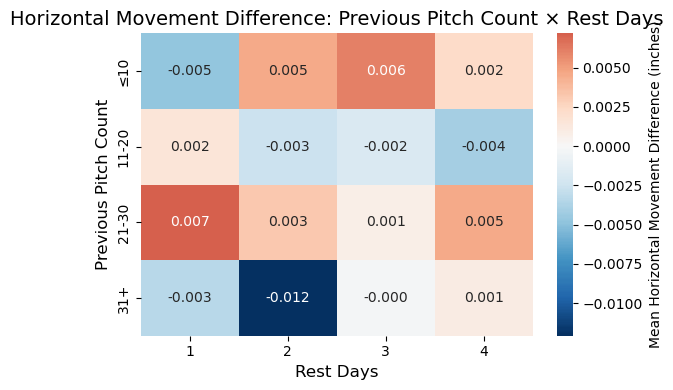

In [6]:
# 3. Horizontal Movement Heatmap
h_movement_heatmap = (outing_table
    .filter((pl.col('rest_days') >= 1) & (pl.col('rest_days') <= 4) & 
            (pl.col('prev_pitch_count').is_not_null()))
    .with_columns([
        pl.col('mean_h_movement').mean().over(['pitcher_id', 'year']).alias('season_avg_h_movement'),
        pl.when(pl.col('prev_pitch_count') <= 10)
          .then(pl.lit('≤10'))
          .when(pl.col('prev_pitch_count') <= 20)
          .then(pl.lit('11-20'))
          .when(pl.col('prev_pitch_count') <= 30)
          .then(pl.lit('21-30'))
          .otherwise(pl.lit('31+'))
          .alias('prev_pitch_bin')
    ])
    .with_columns([
        (pl.col('mean_h_movement') - pl.col('season_avg_h_movement')).alias('h_movement_diff')
    ])
    .group_by(['prev_pitch_bin', 'rest_days'])
    .agg([
        pl.col('h_movement_diff').mean().alias('mean_h')
    ])
    .to_pandas()
    .pivot(index='prev_pitch_bin', columns='rest_days', values='mean_h')
)

h_movement_heatmap = h_movement_heatmap.reindex(['≤10', '11-20', '21-30', '31+'])

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(h_movement_heatmap, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Mean Horizontal Movement Difference (inches)'}, ax=ax)
ax.set_title('Horizontal Movement Difference: Previous Pitch Count × Rest Days', fontsize=14)
ax.set_xlabel('Rest Days', fontsize=12)
ax.set_ylabel('Previous Pitch Count', fontsize=12)
plt.tight_layout()
plt.show()

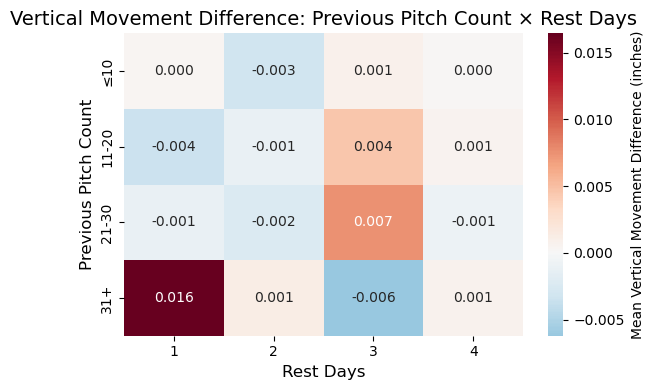

In [7]:
# 4. Vertical Movement Heatmap
v_movement_heatmap = (outing_table
    .filter((pl.col('rest_days') >= 1) & (pl.col('rest_days') <= 4) & 
            (pl.col('prev_pitch_count').is_not_null()))
    .with_columns([
        pl.col('mean_v_movement').mean().over(['pitcher_id', 'year']).alias('season_avg_v_movement'),
        pl.when(pl.col('prev_pitch_count') <= 10)
          .then(pl.lit('≤10'))
          .when(pl.col('prev_pitch_count') <= 20)
          .then(pl.lit('11-20'))
          .when(pl.col('prev_pitch_count') <= 30)
          .then(pl.lit('21-30'))
          .otherwise(pl.lit('31+'))
          .alias('prev_pitch_bin')
    ])
    .with_columns([
        (pl.col('mean_v_movement') - pl.col('season_avg_v_movement')).alias('v_movement_diff')
    ])
    .group_by(['prev_pitch_bin', 'rest_days'])
    .agg([
        pl.col('v_movement_diff').mean().alias('mean_v')
    ])
    .to_pandas()
    .pivot(index='prev_pitch_bin', columns='rest_days', values='mean_v')
)

v_movement_heatmap = v_movement_heatmap.reindex(['≤10', '11-20', '21-30', '31+'])

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(v_movement_heatmap, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Mean Vertical Movement Difference (inches)'}, ax=ax)
ax.set_title('Vertical Movement Difference: Previous Pitch Count × Rest Days', fontsize=14)
ax.set_xlabel('Rest Days', fontsize=12)
ax.set_ylabel('Previous Pitch Count', fontsize=12)
plt.tight_layout()
plt.show()

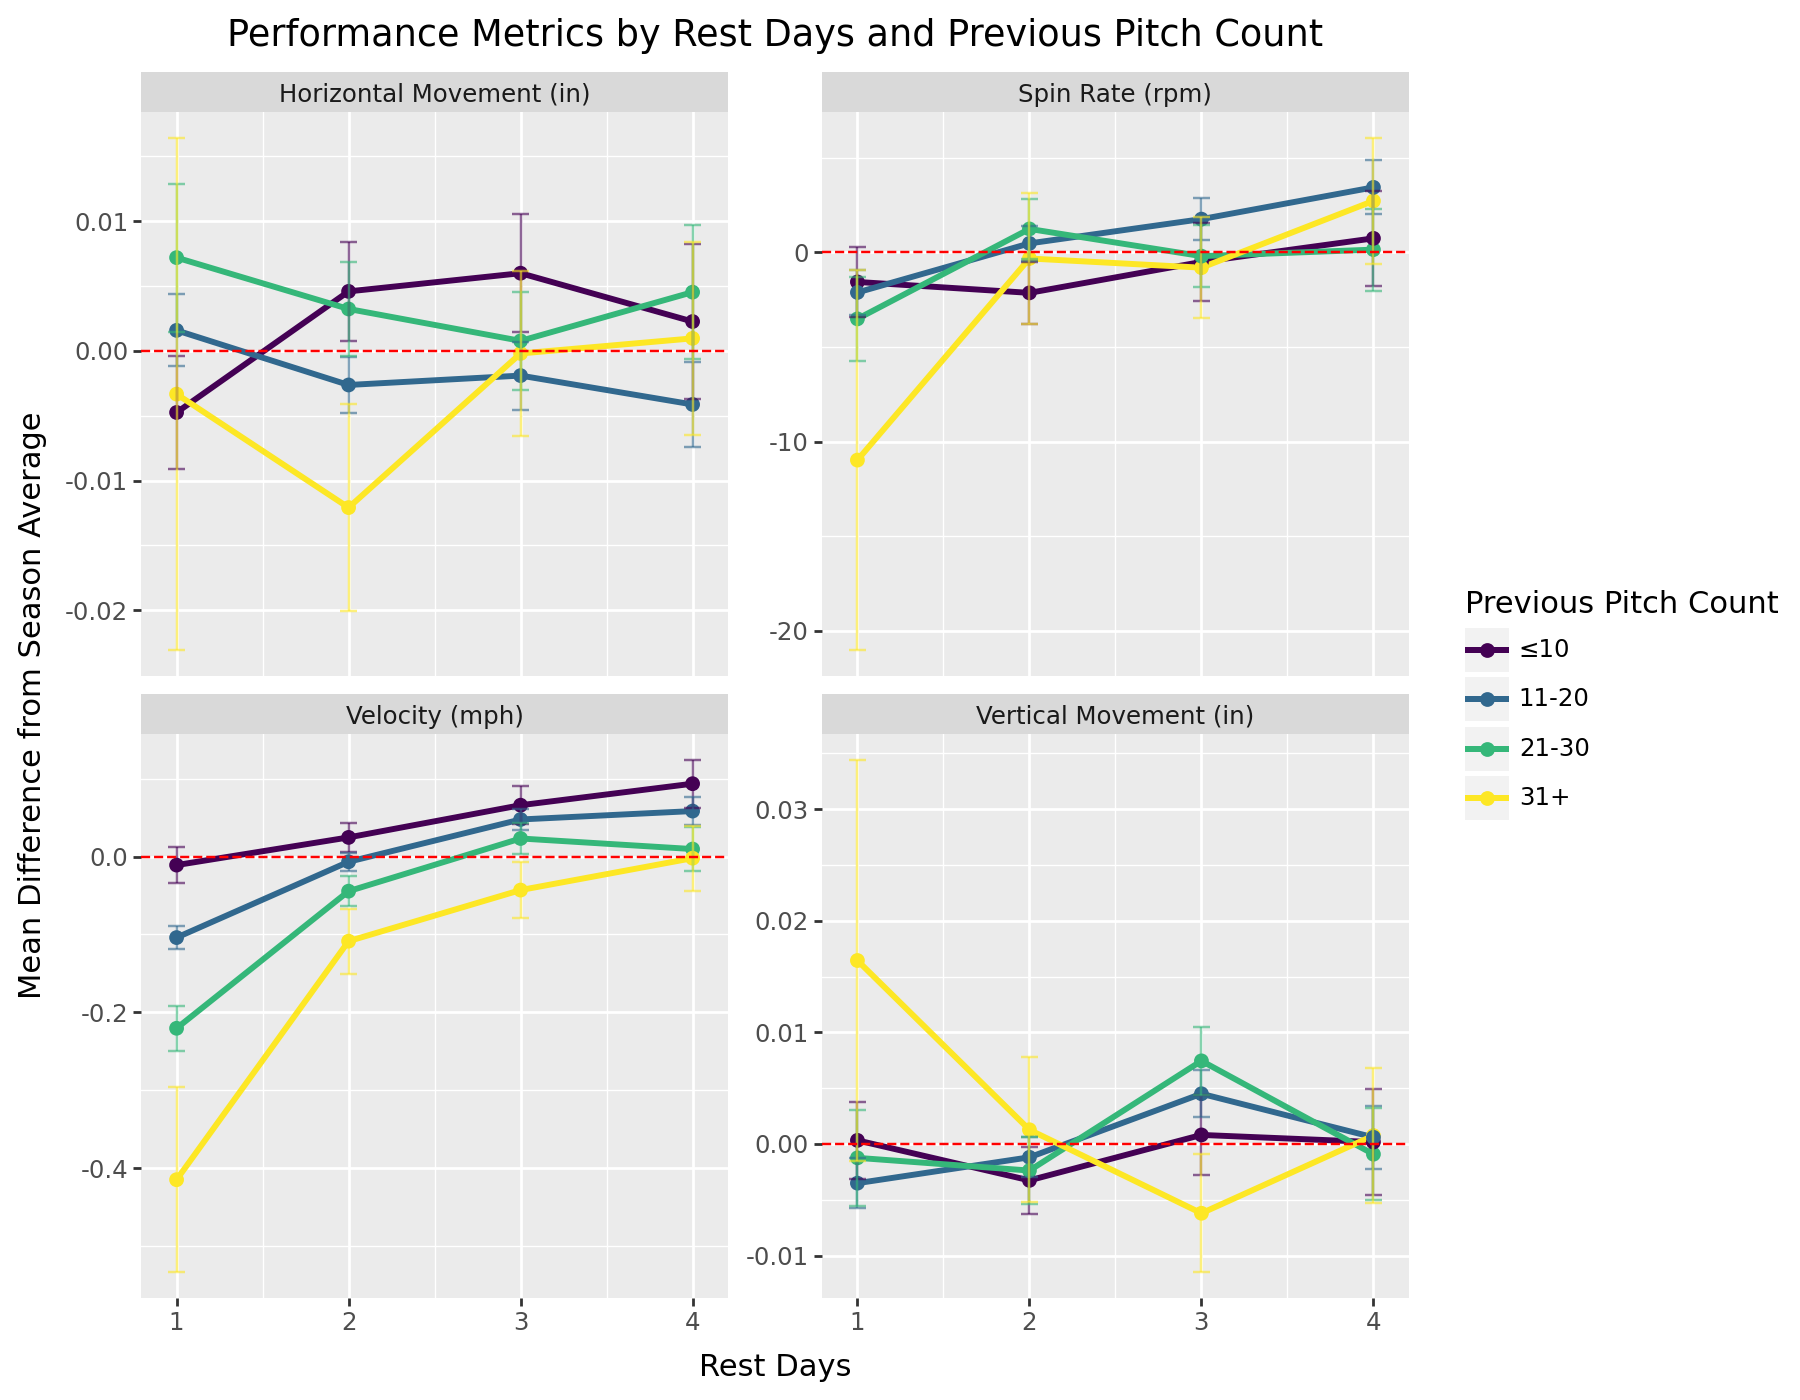

In [8]:
# Calculate means for all 4 metrics
line_data = (outing_table
    .filter((pl.col('rest_days') >= 1) & (pl.col('rest_days') <= 4) & 
            (pl.col('prev_pitch_count').is_not_null()))
    .with_columns([
        pl.col('mean_h_movement').mean().over(['pitcher_id', 'year']).alias('season_avg_h_movement'),
        pl.col('mean_v_movement').mean().over(['pitcher_id', 'year']).alias('season_avg_v_movement'),
        pl.when(pl.col('prev_pitch_count') <= 10)
          .then(pl.lit('≤10'))
          .when(pl.col('prev_pitch_count') <= 20)
          .then(pl.lit('11-20'))
          .when(pl.col('prev_pitch_count') <= 30)
          .then(pl.lit('21-30'))
          .otherwise(pl.lit('31+'))
          .alias('prev_pitch_bin')
    ])
    .with_columns([
        (pl.col('mean_h_movement') - pl.col('season_avg_h_movement')).alias('h_movement_diff'),
        (pl.col('mean_v_movement') - pl.col('season_avg_v_movement')).alias('v_movement_diff')
    ])
    .group_by(['rest_days', 'prev_pitch_bin'])
    .agg([
        pl.col('velo_deviation').mean().alias('mean_velo'),
        pl.col('spin_deviation').mean().alias('mean_spin'),
        pl.col('h_movement_diff').mean().alias('mean_h'),
        pl.col('v_movement_diff').mean().alias('mean_v'),
        pl.col('velo_deviation').std().alias('std_velo'),
        pl.col('spin_deviation').std().alias('std_spin'),
        pl.col('h_movement_diff').std().alias('std_h'),
        pl.col('v_movement_diff').std().alias('std_v'),
        pl.len().alias('n')
    ])
    .with_columns([
        (pl.col('std_velo') / pl.col('n').sqrt()).alias('se_velo'),
        (pl.col('std_spin') / pl.col('n').sqrt()).alias('se_spin'),
        (pl.col('std_h') / pl.col('n').sqrt()).alias('se_h'),
        (pl.col('std_v') / pl.col('n').sqrt()).alias('se_v')
    ])
    .to_pandas()
)

# Reshape for faceting
velo_df = line_data[['rest_days', 'prev_pitch_bin', 'mean_velo', 'se_velo']].copy()
velo_df['metric'] = 'Velocity (mph)'
velo_df.columns = ['rest_days', 'prev_pitch_bin', 'mean', 'se', 'metric']

spin_df = line_data[['rest_days', 'prev_pitch_bin', 'mean_spin', 'se_spin']].copy()
spin_df['metric'] = 'Spin Rate (rpm)'
spin_df.columns = ['rest_days', 'prev_pitch_bin', 'mean', 'se', 'metric']

h_df = line_data[['rest_days', 'prev_pitch_bin', 'mean_h', 'se_h']].copy()
h_df['metric'] = 'Horizontal Movement (in)'
h_df.columns = ['rest_days', 'prev_pitch_bin', 'mean', 'se', 'metric']

v_df = line_data[['rest_days', 'prev_pitch_bin', 'mean_v', 'se_v']].copy()
v_df['metric'] = 'Vertical Movement (in)'
v_df.columns = ['rest_days', 'prev_pitch_bin', 'mean', 'se', 'metric']

combined = pd.concat([velo_df, spin_df, h_df, v_df])

# Set ordering
combined['prev_pitch_bin'] = pd.Categorical(
    combined['prev_pitch_bin'],
    categories=['≤10', '11-20', '21-30', '31+'],
    ordered=True
)

(ggplot(combined, aes(x='rest_days', y='mean', color='prev_pitch_bin', group='prev_pitch_bin')) +
 geom_line(size=1.2) +
 geom_point(size=2) +
 geom_errorbar(aes(ymin='mean - se', ymax='mean + se'), width=0.1, alpha=0.6) +
 geom_hline(yintercept=0, linetype='dashed', color='red', size=0.5) +
 facet_wrap('~metric', scales='free_y', ncol=2) +
 labs(title='Performance Metrics by Rest Days and Previous Pitch Count',
      x='Rest Days',
      y='Mean Difference from Season Average',
      color='Previous Pitch Count') +
 scale_x_continuous(breaks=[1, 2, 3, 4]) +
 theme(figure_size=(9, 7)))

In [9]:
# Statistical test: 31+ pitches at 1 day rest vs ≤10 pitches at 1 day rest
from scipy import stats

test_data = (outing_table
    .filter((pl.col('rest_days') == 1) & (pl.col('prev_pitch_count').is_not_null()))
    .with_columns([
        pl.when(pl.col('prev_pitch_count') <= 10)
          .then(pl.lit('low'))
          .when(pl.col('prev_pitch_count') > 30)
          .then(pl.lit('high'))
          .otherwise(None)
          .alias('workload_group')
    ])
    .drop_nulls('workload_group')
)

low_workload = test_data.filter(pl.col('workload_group') == 'low')['velo_deviation'].to_numpy()
high_workload = test_data.filter(pl.col('workload_group') == 'high')['velo_deviation'].to_numpy()

t_stat, p_value = stats.ttest_ind(high_workload, low_workload)

print("="*60)
print("VELOCITY TEST: High Workload vs Low Workload at 1 Day Rest")
print("="*60)
print(f"\nLow workload (≤10 pitches):")
print(f"  Mean velocity: {low_workload.mean():.3f} mph")
print(f"  n = {len(low_workload)}")

print(f"\nHigh workload (31+ pitches):")
print(f"  Mean velocity: {high_workload.mean():.3f} mph")
print(f"  n = {len(high_workload)}")

print(f"\nDifference: {high_workload.mean() - low_workload.mean():.3f} mph")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.6f}")
print(f"Significant at p < 0.05: {p_value < 0.05}")
print("="*60)

VELOCITY TEST: High Workload vs Low Workload at 1 Day Rest

Low workload (≤10 pitches):
  Mean velocity: -0.011 mph
  n = 1715

High workload (31+ pitches):
  Mean velocity: -0.415 mph
  n = 64

Difference: -0.404 mph
t-statistic: -3.368
p-value: 0.000774
Significant at p < 0.05: True


In [10]:
# Overall statistical tests: Do rest days and pitch count predict performance?
from scipy import stats
import numpy as np

# Prepare data (rest days 1-4)
reg_data = (outing_table
    .filter((pl.col('rest_days') >= 1) & (pl.col('rest_days') <= 4) & 
            (pl.col('prev_pitch_count').is_not_null()))
    .with_columns([
        pl.col('mean_h_movement').mean().over(['pitcher_id', 'year']).alias('season_avg_h_movement'),
        pl.col('mean_v_movement').mean().over(['pitcher_id', 'year']).alias('season_avg_v_movement')
    ])
    .with_columns([
        (pl.col('mean_h_movement') - pl.col('season_avg_h_movement')).alias('h_movement_diff'),
        (pl.col('mean_v_movement') - pl.col('season_avg_v_movement')).alias('v_movement_diff')
    ])
    .select(['rest_days', 'prev_pitch_count', 'velo_deviation', 'spin_deviation', 
             'h_movement_diff', 'v_movement_diff'])
    .to_pandas()
)

metrics = {
    'Velocity (mph)': 'velo_deviation',
    'Spin Rate (rpm)': 'spin_deviation',
    'Horizontal Movement (in)': 'h_movement_diff',
    'Vertical Movement (in)': 'v_movement_diff'
}

print("="*80)
print("OVERALL PREDICTORS OF PERFORMANCE")
print("="*80)

for metric_name, col_name in metrics.items():
    y = reg_data[col_name].dropna()
    X_rest = reg_data.loc[y.index, 'rest_days']
    X_pitch = reg_data.loc[y.index, 'prev_pitch_count']
    
    # Test 1: Rest days
    slope_rest, intercept_rest, r_rest, p_rest, se_rest = stats.linregress(X_rest, y)
    
    # Test 2: Previous pitch count
    slope_pitch, intercept_pitch, r_pitch, p_pitch, se_pitch = stats.linregress(X_pitch, y)
    
    print(f"\n{metric_name}:")
    print(f"  Rest Days:          slope={slope_rest:+.4f}, p={p_rest:.6f} {'***' if p_rest < 0.001 else '**' if p_rest < 0.01 else '*' if p_rest < 0.05 else 'ns'}")
    print(f"  Prev Pitch Count:   slope={slope_pitch:+.4f}, p={p_pitch:.6f} {'***' if p_pitch < 0.001 else '**' if p_pitch < 0.01 else '*' if p_pitch < 0.05 else 'ns'}")

print("\n" + "="*80)
print("*** p<0.001  ** p<0.01  * p<0.05  ns = not significant")
print("Positive slope = metric IMPROVES with more rest/pitches")
print("Negative slope = metric WORSENS with more rest/pitches")

OVERALL PREDICTORS OF PERFORMANCE

Velocity (mph):
  Rest Days:          slope=+0.0512, p=0.000000 ***
  Prev Pitch Count:   slope=-0.0031, p=0.000005 ***

Spin Rate (rpm):
  Rest Days:          slope=+1.3611, p=0.001324 **
  Prev Pitch Count:   slope=+0.0371, p=0.500082 ns

Horizontal Movement (in):
  Rest Days:          slope=-0.0003, p=0.769798 ns
  Prev Pitch Count:   slope=-0.0000, p=0.801095 ns

Vertical Movement (in):
  Rest Days:          slope=+0.0016, p=0.049750 *
  Prev Pitch Count:   slope=+0.0002, p=0.074687 ns

*** p<0.001  ** p<0.01  * p<0.05  ns = not significant
Positive slope = metric IMPROVES with more rest/pitches
Negative slope = metric WORSENS with more rest/pitches


In [21]:
(summary_table := (
    outing_table
    .filter(
        (pl.col("rest_days") >= 1) &
        (pl.col("rest_days") <= 5) &
        (pl.col("prev_pitch_count").is_not_null())
    )
    .with_columns([
        pl.when(pl.col("prev_pitch_count") <= 10).then(pl.lit("≤10"))
          .when(pl.col("prev_pitch_count") <= 20).then(pl.lit("11-20"))
          .when(pl.col("prev_pitch_count") <= 30).then(pl.lit("21-30"))
          .otherwise(pl.lit("31+"))
          .alias("prev_pitch_bin"),

        pl.when(pl.col("prev_pitch_count") <= 10).then(1)
          .when(pl.col("prev_pitch_count") <= 20).then(2)
          .when(pl.col("prev_pitch_count") <= 30).then(3)
          .otherwise(4)
          .alias("bin_order")
    ])
    .group_by(["rest_days", "prev_pitch_bin", "bin_order"])
    .agg([
        pl.mean("velo_deviation").alias("avg_velo_difference"),
        pl.mean("spin_deviation").alias("avg_spin_difference"),
        pl.len().alias("n")
    ])
    .sort(["rest_days", "bin_order"])
    .drop("bin_order")
    .with_columns([
        pl.col("avg_velo_difference").round(2),
        pl.col("avg_spin_difference").round(0)
    ])
))

rest_days,prev_pitch_bin,avg_velo_difference,avg_spin_difference,n
i64,str,f64,f64,u32
1,"""≤10""",-0.01,-2.0,1715
1,"""11-20""",-0.1,-2.0,4084
1,"""21-30""",-0.22,-4.0,974
1,"""31+""",-0.41,-11.0,64
2,"""≤10""",0.02,-2.0,2063
…,…,…,…,…
4,"""31+""",-0.0,3.0,463
5,"""≤10""",0.15,4.0,378
5,"""11-20""",0.08,2.0,1215


In [22]:
summary_table.write_csv("data/rest_pitch_summary_table_days_bin.csv")